# Model 2: Building Detection (Semantic Segmentation / Counting)

**Goal:** Outline the buildings in the image. We replace a custom CNN classifier with a U-Net architecture designed specifically for semantic segmentation to produce `solaris`-style masks.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

print('TensorFlow Version:', tf.__version__)

TensorFlow Version: 2.21.0


## 1. U-Net Architecture
A standard U-Net with contracting path (encoder) and expansive path (decoder). Useful for dense pixel prediction.

In [2]:
def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)
    
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)

    # Decoder
    u5 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    u6 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c6)
    
    u7 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c7) # Binary mask output

    model = models.Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

unet_model = build_unet()
unet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │    524,544 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │  1,179,904 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │    131,200 │ conv2d_9[0][0]  

 Total params: 7,697,345 (29.36 MB)

 Trainable params: 7,697,345 (29.36 MB)

 Non-trainable params: 0 (0.00 B)

## 2. Generating Masks from JSON labels
To train this U-Net, you will use `cv2.fillPoly` to convert the `wkt` polygons from `test/labels/` into binary ground-truth masks where `1` equals building and `0` equals background.

## 3. Data Pipeline & Training
We use a cv2-based generator for fast polygon processing.

In [4]:
import os, glob, json, cv2, re
import numpy as np

TRAIN_IMG_DIR = "../train/images"
TRAIN_LBL_DIR = "../train/labels"
TEST_IMG_DIR = "../test/images"
TEST_LBL_DIR = "../test/labels"

def parse_wkt_to_coords(wkt):
    coords_str = re.search(r'\(\((.*?)\)\)', wkt).group(1)
    pts = []
    for pair in coords_str.split(', '):
        x, y = pair.split(' ')
        pts.append([float(x), float(y)])
    return np.array(pts, dtype=np.int32)

def load_image_and_mask(img_path):
    img_path = img_path.numpy().decode('utf-8')
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    
    label_path = img_path.replace("images", "labels").replace(".png", ".json")
    mask = np.zeros((1024, 1024), dtype=np.uint8)
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            data = json.load(f)
        if 'xy' in data['features']:
            for feat in data['features']['xy']:
                pts = parse_wkt_to_coords(feat['wkt'])
                cv2.fillPoly(mask, [pts], 1)
    
    mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
    return img.astype(np.float32), np.expand_dims(mask, axis=-1).astype(np.float32)

def tf_parse(img_path):
    img, mask = tf.py_function(load_image_and_mask, [img_path], [tf.float32, tf.float32])
    img.set_shape([256, 256, 3])
    mask.set_shape([256, 256, 1])
    return img, mask

train_paths = glob.glob(os.path.join(TRAIN_IMG_DIR, "*.png"))
train_ds = tf.data.Dataset.from_tensor_slices(train_paths[:500])
train_ds = train_ds.map(tf_parse, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(100).batch(16).prefetch(tf.data.AUTOTUNE)

print("Training Unet...")
history = unet_model.fit(train_ds, epochs=5)
unet_model.save("building_segmentation.h5")
print("Saved Model")


Training Unet...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 655s 21s/step - accuracy: 0.8903 - loss: 0.8500
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 646s 20s/step - accuracy: 0.9344 - loss: 0.2326
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 639s 20s/step - accuracy: 0.9351 - loss: 0.2050
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1598s 51s/step - accuracy: 0.9367 - loss: 0.1888
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 743s 23s/step - accuracy: 0.9312 - loss: 0.2202


Saved Model


## 4. Test Set Evaluation
Let's evaluate the U-Net accuracy on the unseen test set.

In [5]:
test_paths = glob.glob(os.path.join(TEST_IMG_DIR, "*.png"))
# We will evaluate on a small subset to keep it fast
test_ds = tf.data.Dataset.from_tensor_slices(test_paths[:100])
test_ds = test_ds.map(tf_parse, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(16).prefetch(tf.data.AUTOTUNE)

print("Evaluating U-Net on Test Set...")
results = unet_model.evaluate(test_ds)
print(f"Test Loss: {results[0]:.4f}, Test Accuracy: {results[1]:.4f}")


Evaluating U-Net on Test Set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 50s 7s/step - accuracy: 0.9341 - loss: 0.2131
Test Loss: 0.2131, Test Accuracy: 0.9341


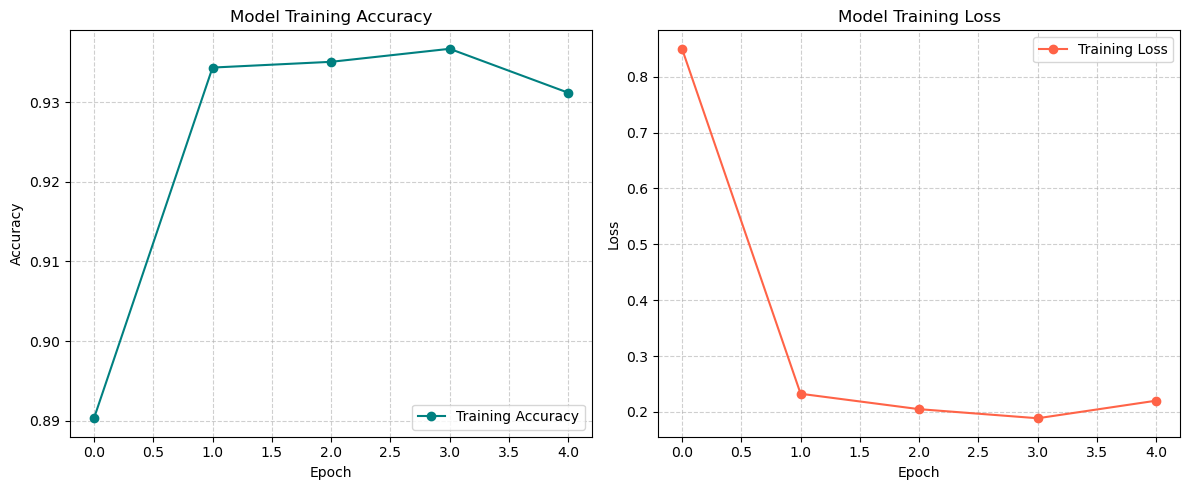

In [25]:
import matplotlib.pyplot as plt

# Plotting the training results
def plot_history(history):
    acc = history.history['accuracy']
    loss = history.history['loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='teal')
    plt.title('Model Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower right')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='tomato')
    plt.title('Model Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_history(history)


In [33]:
def display_predictions(dataset, model, num_samples=3, image_paths=None):
    # Take a batch from the dataset
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        # Threshold the prediction to create a binary mask
        preds_binary = (preds > 0.1).astype(np.float32)

        for i in range(min(num_samples, len(images))):
            # Extract filename if available
            filename_str = ""
            if image_paths is not None and i < len(image_paths):
                import os
                filename = os.path.basename(image_paths[i])
                filename_str = f"\n({filename})"
                print(f"Checking image: {filename}")
                
            plt.figure(figsize=(15, 5))
            
            # 1. Original Image
            plt.subplot(1, 3, 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"Sample {i+1}: Original Image{filename_str}")
            plt.axis("off")
            
            # 2. Actual Label (Ground Truth)
            plt.subplot(1, 3, 2)
            plt.imshow(masks[i].numpy().squeeze(), cmap='gray')
            plt.title("Actual Building Mask")
            plt.axis("off")
            
            # 3. Model Output (Prediction)
            plt.subplot(1, 3, 3)
            plt.imshow(preds_binary[i].squeeze(), cmap='magma')
            plt.title("Predicted Building Mask")
            plt.axis("off")
            
            plt.tight_layout()
            plt.show()

print("Visualization function defined.")

Visualization function defined.


In [30]:
from tensorflow.keras.models import load_model

# Load the entire model from the H5 file
model = load_model('building_segmentation.h5')

# Verify the architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │    524,544 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │  1,179,904 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │    131,200 │ conv2d_9[0][0]  

 Total params: 7,697,347 (29.36 MB)

 Trainable params: 7,697,345 (29.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Generating predictions for test samples...
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Checking image: hurricane-harvey_00000483_post_disaster.png


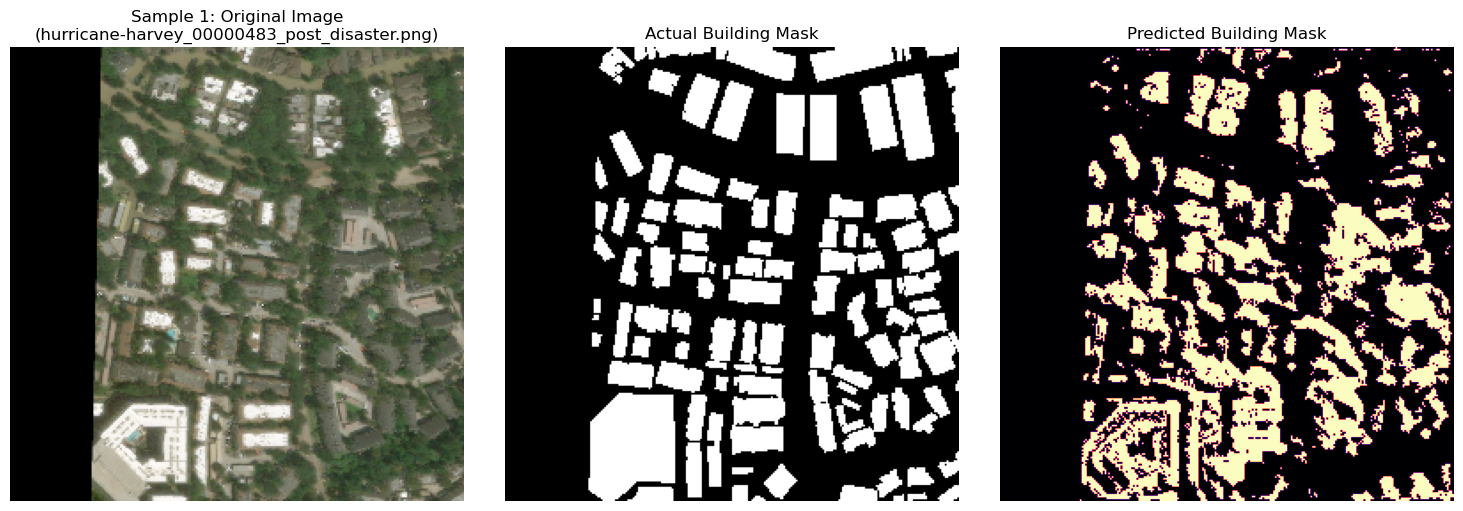

Checking image: socal-fire_00001098_pre_disaster.png


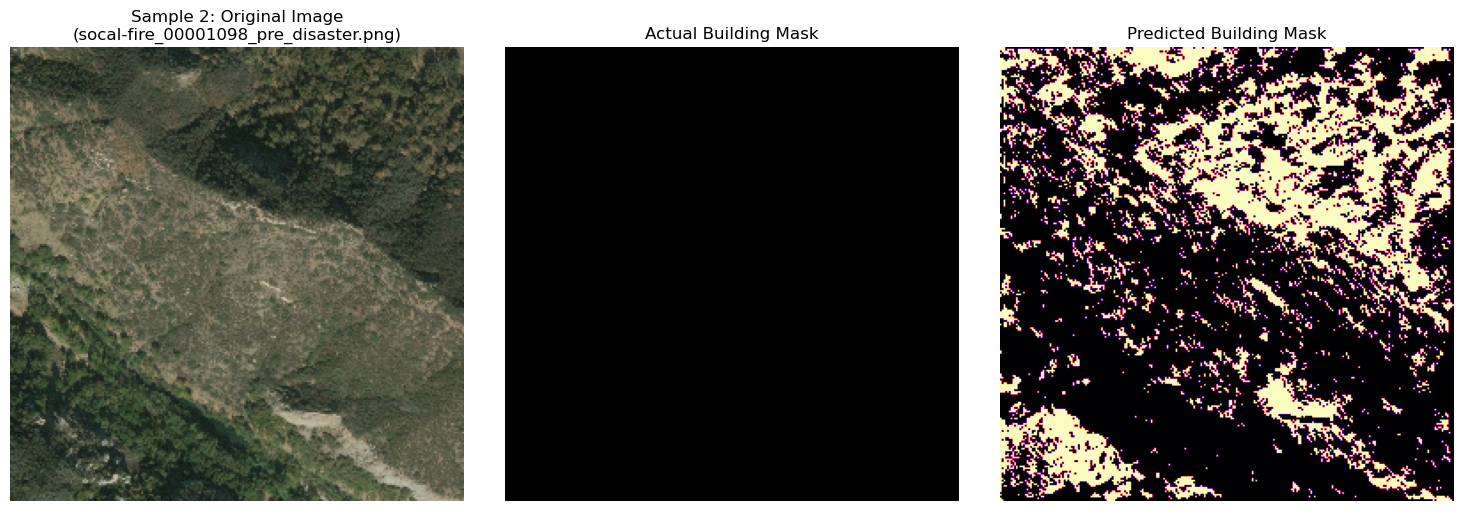

Checking image: hurricane-florence_00000301_pre_disaster.png


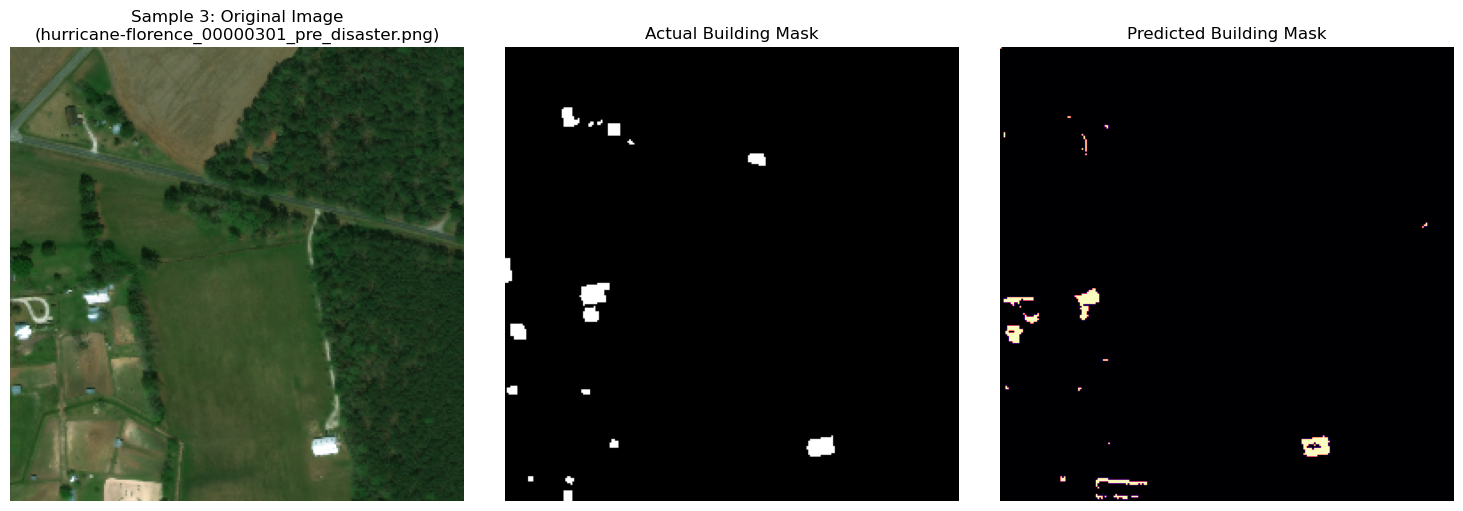

Checking image: hurricane-florence_00000235_post_disaster.png


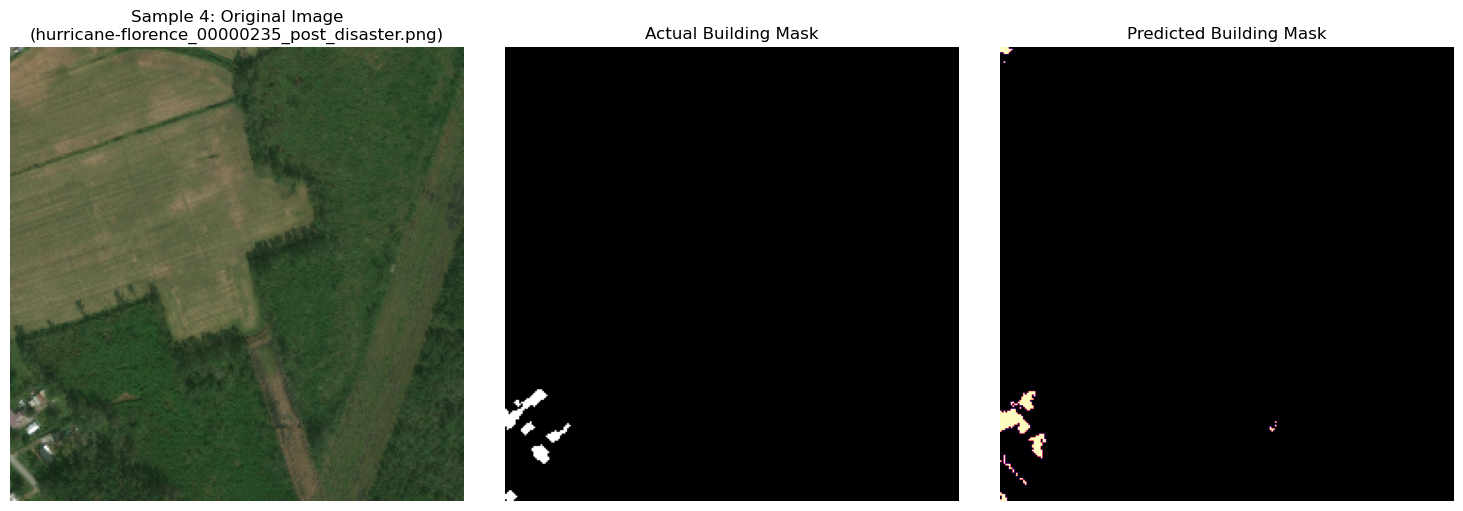

In [34]:
# Visualize results on the unseen test set
unet_model = model

print("Generating predictions for test samples...")
display_predictions(test_ds, unet_model, num_samples=4, image_paths=test_paths)